# IPEDS Paper Artifacts (Code Sections)
This notebook provides a separate, runnable code section for each figure and table used in the paper.


## Figure 1 — Pipeline Diagram

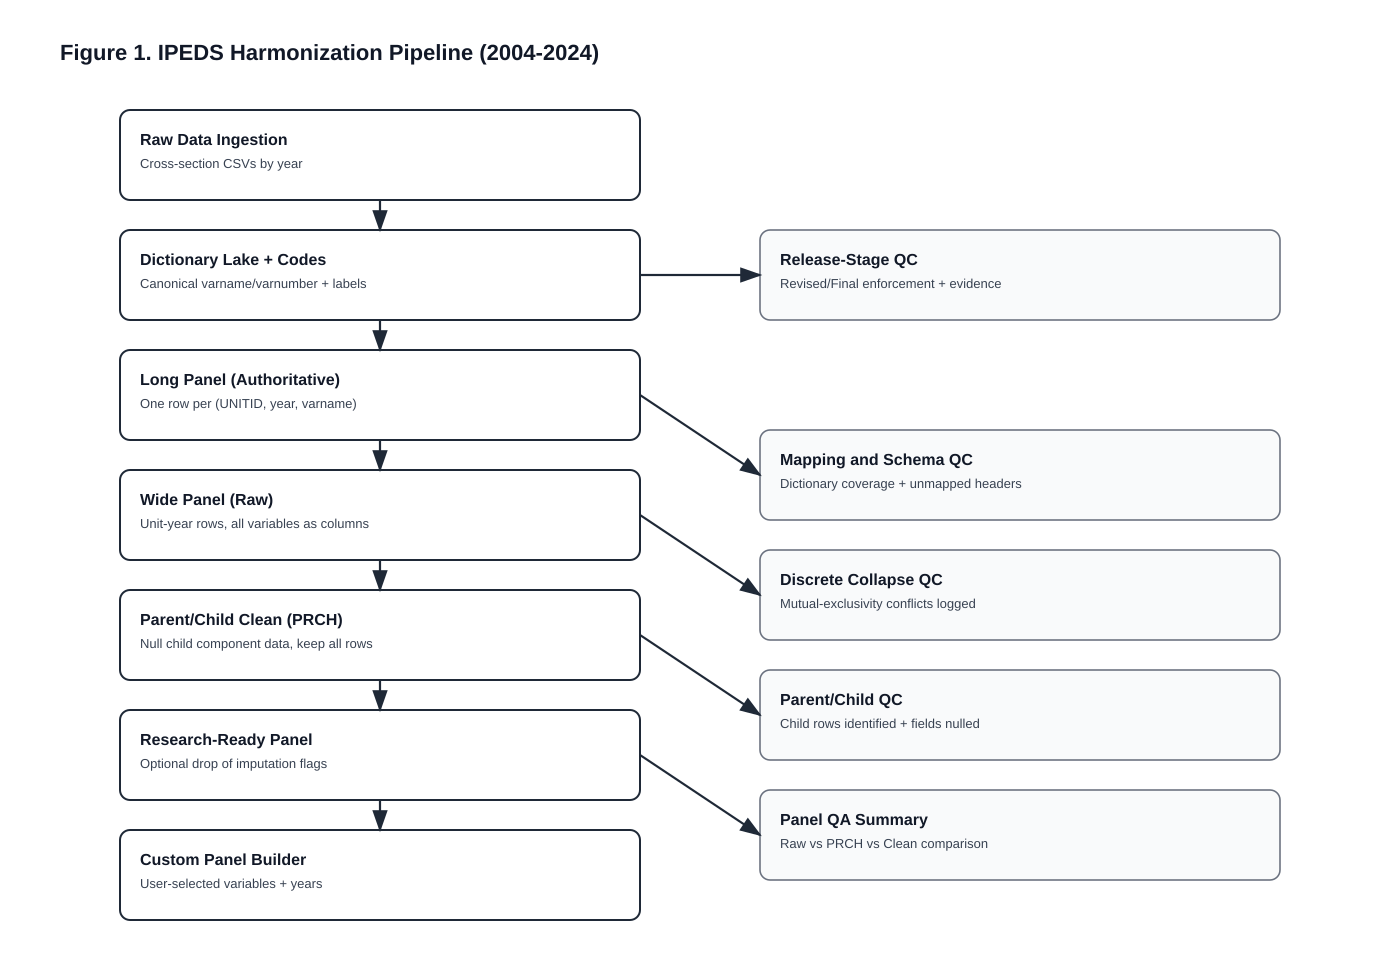

In [13]:
from pathlib import Path
from IPython.display import SVG, display

cwd = Path.cwd()
root = next((p for p in [cwd] + list(cwd.parents) if (p / 'Artifacts').exists()), None)
if root is None:
    raise FileNotFoundError('Could not locate repo root with Artifacts/ directory')
svg_path = root / 'Artifacts' / 'Figure_1_pipeline.svg'
display(SVG(filename=str(svg_path)))


## Section 5 — Evaluation & Validation (Draft Text)

In [14]:
from pathlib import Path

cwd = Path.cwd()
root = next((p for p in [cwd] + list(cwd.parents) if (p / 'Artifacts').exists()), None)
if root is None:
    raise FileNotFoundError('Could not locate repo root with Artifacts/ directory')
path = root / 'Artifacts' / 'section5_validation.md'
print(path.read_text())


# 5. Evaluation and Validation

This section reports validation metrics produced by the pipeline’s built‑in QC artifacts.  
All numbers below are reproducible from the Parquet outputs and QC directories.

## 5.1 Release‑stage validation

**Claim.** Restricting inputs to revised/final releases reduces non‑substantive breaks caused by provisional revisions.  
**Evidence.** The recommended run enforces revised/final when available and writes release QC outputs.

**Report from QC (`Checks/release_qc/`):**
- Number of component files included per year  
- Number of files excluded due to disallowed release stage  
- Years with missing required components under strict mode

## 5.2 Mapping coverage and schema‑drift mitigation

**Claim.** Dictionary‑first mapping yields stable variable identities across years.  
**Evidence.** The dictionary lake defines canonical `(varnumber, varname)`, and long‑panel rows retain `source_file` provenance.

**Report from dictionary + long panel:**
- Total dictio

## Table 3 — Metrics Template

In [15]:
from pathlib import Path
import pandas as pd

cwd = Path.cwd()
root = next((p for p in [cwd] + list(cwd.parents) if (p / 'Artifacts').exists()), None)
if root is None:
    raise FileNotFoundError('Could not locate repo root with Artifacts/ directory')
path = root / 'Artifacts' / 'table3_validation_metrics_template.csv'
df = pd.read_csv(path)
df


,section,metric,value,units,source,notes
0,5.1 Release-stage validation,Included component files (median per year),NaN,files/year,Checks/release_qc/release_details_YYYY.csv,Median across years
1,5.1 Release-stage validation,Excluded files (median per year),NaN,files/year,Checks/release_qc/release_details_YYYY.csv,Non-revised/final when revised exists
2,5.2 Mapping coverage,Dictionary rows (total),NaN,rows,Dictionary/dictionary_lake.parquet,Variable-year definitions
3,5.2 Mapping coverage,Unique canonical variables,NaN,vars,Dictionary/dictionary_lake.parquet,Max across years
4,5.2 Mapping coverage,Percent raw columns mapped (median),NaN,share,Raw headers vs dictionary,Requires --scan-raw
5,5.3 Long-panel integrity,Duplicate key rate (median),NaN,share,Long panel parquet,"Duplicates on (UNITID, year, varname)"
6,5.3 Long-panel integrity,Coverage share (median),NaN,share,Long panel parquet,Vars with any data / total vars
7,5.4 Discrete collapse conflicts,Total conflicts (all years),NaN,rows,Checks/disc_qc/*.csv,More than one active category
8,5.5 Parent/child validation,Child institution-years identified,NaN,rows,Checks/prch_qc/prch_clean_summary.csv,Sum across PRCH flags


## Reproducible Metrics — Generate Table 3 Inputs

In [16]:
!python3 /Users/markjaysonfarol13/Documents/GitHub/IPEDS_Paneling/09_build_audit_pack.py \
  --out-dir 'audit_pack' \
  --zip \
  --years '2004:2024' \
  --raw-root '/Users/markjaysonfarol13/IPEDS_Paneling/Raw_Cross_Section_Data' \
  --checks-dir '/Users/markjaysonfarol13/IPEDS_Paneling/Checks' \
  --dictionary '/Users/markjaysonfarol13/IPEDS_Paneling/Dictionary/dictionary_lake.parquet' \
  --dictionary-codes '/Users/markjaysonfarol13/IPEDS_Paneling/Dictionary/dictionary_codes.parquet' \
  --long-panel '/Users/markjaysonfarol13/IPEDS_Paneling/Panels/2004-2024/panel_long_varnum_2004_2024.parquet' \
  --wide-raw '/Users/markjaysonfarol13/IPEDS_Paneling/Panels/2004_2024_IPEDS_Raw_Panel_DS.parquet' \
  --wide-prch '/Users/markjaysonfarol13/IPEDS_Paneling/Panels/2004_2024_IPEDS_PRCHclean_Panel_DS.parquet' \
  --wide-clean '/Users/markjaysonfarol13/IPEDS_Paneling/Panels/2004_2024_IPEDS_clean_Panel_DS.parquet'


Traceback (most recent call last):
  File "/Users/markjaysonfarol13/Documents/GitHub/IPEDS_Paneling/09_paper_metrics.py", line 319, in <module>
    main()
    ~~~~^^
  File "/Users/markjaysonfarol13/Documents/GitHub/IPEDS_Paneling/09_paper_metrics.py", line 288, in main
    release_df = summarize_release_qc(Path(args.release_qc_dir), years)
  File "/Users/markjaysonfarol13/Documents/GitHub/IPEDS_Paneling/09_paper_metrics.py", line 49, in summarize_release_qc
    included = int(allowed.sum())
ValueError: invalid literal for int() with base 10: 'TrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrueTrue'
